# Анализ алгоритмов

In [1]:
import geopandas as gpd
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from genesis.metrics import *
# from genesis.core import BestPointsBase, StateBase
from genesis.states import FirstArrivalUnitState
from genesis.utils import Progressbar, timing
# from genesis.best_points import 

# Загрузка исходных данных и разбиение по районам

31293 77344
Районы Красноярска: ['Железнодорожный район', 'Кировский район', 'Ленинский район', 'Октябрьский район', 'Свердловский район', 'Советский район', 'Центральный район']
Всего зданий в Красноярске: 58094


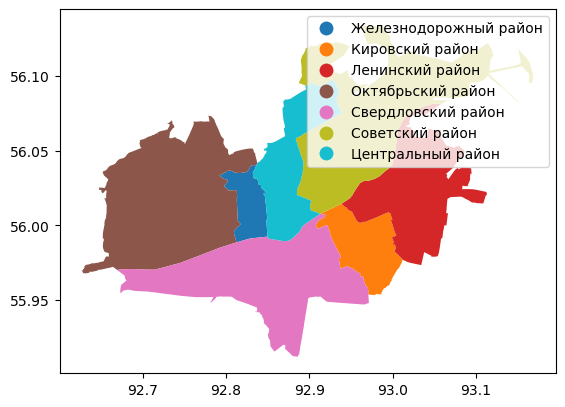

In [80]:
map_path = 'D:/QGIS/_Красноярск ДИССЕРТАЦИЯ'

# ГДС
G = ox.load_graphml(map_path+"/fire_data/rng.ml")
print(G.number_of_nodes(), G.number_of_edges())

# районы
districts = gpd.read_file(map_path+"/data/districts.gpkg", layer='Районы')
districts = districts.set_index(districts['name'])
districts.plot(column='name', legend=True)
print('Районы Красноярска:', list(districts.index))

# здания
buildings = gpd.read_file(map_path+"/data/bld.gpkg", layer='здания')
buildings = buildings[['osmid', 'name', 'amenity', 'building', 'kfpo_spros', 'geometry']]
buildings = buildings.set_index('osmid')
print('Всего зданий в Красноярске:', len(buildings))

In [81]:
print('Проверка СК:', end=' ')
if not G.graph['crs'] == districts.crs == buildings.crs:
    raise ValueError('CRS G, districts и buildings различны!')
else:
    print('CRS совпадают.')

Проверка СК: CRS совпадают.


In [82]:
G = ox.project_graph(G)
districts = ox.project_gdf(districts)
buildings = ox.project_gdf(buildings)

print('Проверка СК:', end=' ')
if not G.graph['crs'] == districts.crs == buildings.crs:
    raise ValueError('CRS G, districts и buildings различны!')
else:
    print('CRS совпадают.')

Проверка СК: CRS совпадают.


In [83]:
g_nodes = ox.graph_to_gdfs(G, edges=False)

scopes = {}
for i, district in districts.iterrows():
    poly = district['geometry']
    print(f'{i}: ', end='')

    # Граф
    g_nodes_in = g_nodes.loc[g_nodes.intersects(poly.buffer(1000))]
    g = nx.subgraph(G, g_nodes_in.index)
    # оставляем только больший сильносвязный компонент:
    # g = max(nx.strongly_connected_components(g), key=len)
    g = nx.subgraph(g, max(nx.strongly_connected_components(g), key=len))
    print(g.number_of_nodes(), g.number_of_edges(), end=' ')

    # Здания
    b = buildings.loc[buildings.intersects(poly)]
    print(len(b))

    scopes[i] = [poly, g, b]

Железнодорожный район: 3515 8411 2952
Кировский район: 5100 12939 3526
Ленинский район: 5953 15022 5255
Октябрьский район: 7008 17201 13209
Свердловский район: 5490 13597 17432
Советский район: 9377 22942 9048
Центральный район: 5641 13763 6687


In [ ]:
def plot_g(name, g, b, poly, ax):
    ax.set_title(name)
    ax.set_axis_off()
    ax.set_facecolor('white')
    ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax, show=False)
    b.plot(ax=ax)
    poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax)


# fig, axs = plt.subplots(4,2, tight_layout=True, figsize=(8,16))  #, dpi=300)
fig, axs = plt.subplots(3,3, tight_layout=True, figsize=(12,12), dpi=300)
x,y = 0,0
for district in districts.index:
    print(f'{district} [{y,x}]: ', end='')
    g = scopes[district][1]
    b = scopes[district][2]
    plot_g(district, g, b, districts.loc[[district]], axs[y,x])
    x += 1
    if x >= 3:
        x = 0
        y += 1
    print('ok')

ax=axs[2,1]
ax.set_title('г. Красноярск')
ax.set_axis_off()
ax.set_facecolor('white')
districts.plot(column='name', ax=ax, legend=True, legend_kwds={'fontsize': 6, 'markerscale':0.5})

plt.delaxes(axs[2,2])

fig.tight_layout()